# Quality Control

scPerturb ships precomputed QC metrics (`ngenes`, `ncounts`, `percent_mito`, `percent_ribo`). We apply light filtering — this dataset is already clean, so QC removes very few cells.

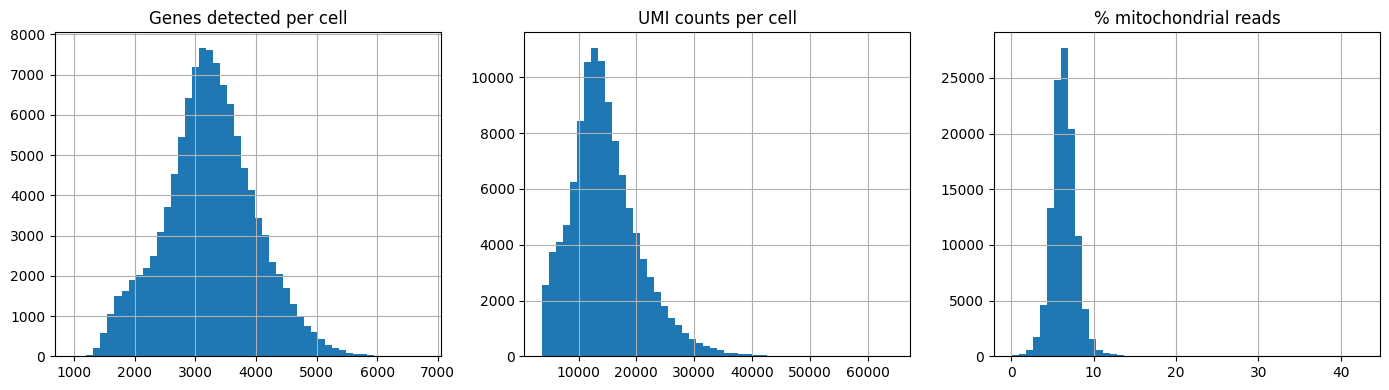

In [1]:
import sys
sys.path.insert(0, '..')
import scanpy as sc
import matplotlib.pyplot as plt

adata = sc.read_h5ad('../data/norman.h5ad')
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
adata.obs['ngenes'].hist(bins=50, ax=axes[0]); axes[0].set_title('Genes detected per cell')
adata.obs['ncounts'].hist(bins=50, ax=axes[1]); axes[1].set_title('UMI counts per cell')
adata.obs['percent_mito'].hist(bins=50, ax=axes[2]); axes[2].set_title('% mitochondrial reads')
fig.tight_layout()

In [2]:
from src.data.preprocessing import run_qc

before = adata.n_obs
filtered = run_qc(adata, min_genes=500, max_percent_mito=20.0)
after = filtered.n_obs
print(f'Cells before QC: {before}')
print(f'Cells after QC:  {after}  ({before - after} removed, {(before-after)/before:.2%})')

Cells before QC: 111445
Cells after QC:  111391  (54 removed, 0.05%)


## Normalization and highly-variable gene selection

Library-size normalize + log1p on all genes (kept for differential-expression analysis), then select the top 2000 highly variable genes as the modeling feature space.

In [3]:
from src.data.preprocessing import normalize

full, hvg = normalize(filtered, n_top_genes=2000)
print(full.shape, hvg.shape)

(111391, 33694) (111391, 2000)
